In [57]:
# 1. Загрузка и базовая предобработка данных.

from pathlib import Path
import pandas as pd
import re
import html
import pymorphy3
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

dataset_negative = Path("../../dataset/RuTweetCorp/negative.csv")
dataset_positive = Path("../../dataset/RuTweetCorp/positive.csv")

print("Файлы существуют:", dataset_positive.exists(), dataset_negative.exists())
print("Путь:", dataset_positive, dataset_negative)

Файлы существуют: True True
Путь: ..\..\dataset\RuTweetCorp\positive.csv ..\..\dataset\RuTweetCorp\negative.csv


In [4]:
# смотрим данные первично
df_n = pd.read_csv(dataset_negative)
df_p = pd.read_csv(dataset_positive)

print(df_n.shape, df_p.shape)
print("Негативные твиты", df_n["ttext"].head())
print("Позитивные твиты", df_p["ttext"].head())

(111923, 12) (114911, 12)
Негативные твиты 0    на работе был полный пиддес :| и так каждое за...
1    Коллеги сидят рубятся в Urban terror, а я из-з...
2    @elina_4post как говорят обещаного три года жд...
3    Желаю хорошего полёта и удачной посадки,я буду...
4    Обновил за каким-то лешим surf, теперь не рабо...
Name: ttext, dtype: str
Позитивные твиты 0    @first_timee хоть я и школота, но поверь, у на...
1    Да, все-таки он немного похож на него. Но мой ...
2    RT @KatiaCheh: Ну ты идиотка) я испугалась за ...
3    RT @digger2912: "Кто то в углу сидит и погибае...
4    @irina_dyshkant Вот что значит страшилка :D\nН...
Name: ttext, dtype: str


In [5]:
# смотрим данные подробнее и принимаем решение что конкретно надо удалять
for text in df_n["ttext"].head(10):
    print(text)
    print("-" * 80)

на работе был полный пиддес :| и так каждое закрытие месяца, я же свихнусь так D:
--------------------------------------------------------------------------------
Коллеги сидят рубятся в Urban terror, а я из-за долбанной винды не могу :(
--------------------------------------------------------------------------------
@elina_4post как говорят обещаного три года ждут...((
--------------------------------------------------------------------------------
Желаю хорошего полёта и удачной посадки,я буду очень сильно скучать( http://t.co/jCLNzVNv3S
--------------------------------------------------------------------------------
Обновил за каким-то лешим surf, теперь не работает простоплеер :(
--------------------------------------------------------------------------------
Котёнка вчера носик разбила, плакала и расстраивалась :(
--------------------------------------------------------------------------------
@juliamayko @O_nika55 @and_Possum Зашли, а то он опять затихарился, я прямо физически ст

In [6]:
# функция подготовки текста
def clean_text_for_ml(text: str) -> str:
    if not isinstance(text, str):
        return ""

    text = html.unescape(text)
    text = text.lower()

    # Удаляем URL
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Удаляем упоминания пользователей
    text = re.sub(r"@\w+", " ", text)

    # Удаляем хештеги
    text = re.sub(r"#\w+", " ", text)

    # Удаляем всё, кроме букв, цифр, пробелов и базовой пунктуации
    text = re.sub(r"[^а-яёa-z0-9\s]", " ", text)

    # Убираем повторяющиеся пробелы
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [7]:
# смотрим результат очистки на ограниченной выборке
df_n["clean_text"] = df_n["ttext"].apply(clean_text_for_ml)
df_p["clean_text"] = df_p["ttext"].apply(clean_text_for_ml)

print(df_n[["ttext", "clean_text"]].head(10))
print(df_p[["ttext", "clean_text"]].head(10))

                                               ttext  \
0  на работе был полный пиддес :| и так каждое за...   
1  Коллеги сидят рубятся в Urban terror, а я из-з...   
2  @elina_4post как говорят обещаного три года жд...   
3  Желаю хорошего полёта и удачной посадки,я буду...   
4  Обновил за каким-то лешим surf, теперь не рабо...   
5  Котёнка вчера носик разбила, плакала и расстра...   
6  @juliamayko @O_nika55 @and_Possum Зашли, а то ...   
7       а вообще я не болею -  я не выздоравливаю :(   
8  я микрофраза :( учимся срать кирпичами в режим...   
9  я хочу с тобой помириться , но сука я гордая и...   

                                          clean_text  
0  на работе был полный пиддес и так каждое закры...  
1  коллеги сидят рубятся в urban terror а я из за...  
2                как говорят обещаного три года ждут  
3  желаю хорошего полёта и удачной посадки я буду...  
4  обновил за каким то лешим surf теперь не работ...  
5  котёнка вчера носик разбила плакала и расстраи... 

In [8]:
# Лемматизация
morph = pymorphy3.MorphAnalyzer()

def lemmatize_text(text):
    words = text.split()
    return " ".join(morph.parse(word)[0].normal_form for word in words)

# Тест
text = df_n["clean_text"].iloc[6]

print("ДО:")
print(text)

print("\nПОСЛЕ:")
print(lemmatize_text(text))



df_p["lemmatized_text"] = df_p["clean_text"].apply(lemmatize_text)
df_n["lemmatized_text"] = df_n["clean_text"].apply(lemmatize_text)

ДО:
зашли а то он опять затихарился я прямо физически страдаю когда он долго молчит

ПОСЛЕ:
заслать а то он опять затихариться я прямо физически страдать когда он долго молчать


In [ ]:
# Чтобы модель понимала где позитив, где негатив добавили столбец label для каждой выборки, 1 и 0 соответственно
df_n["label"] = 0
df_p["label"] = 1

# Объеденяем один датафрейм
df = pd.concat([df_n, df_p], ignore_index=True)

print(df.shape)
print(df["label"].value_counts())

(226834, 15)
label
1    114911
0    111923
Name: count, dtype: int64


In [12]:
# Разделили дата фрейм на тест и трейн
train, test = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Train:", train.shape)
print("Test:", test.shape)

Train: (181467, 15)
Test: (45367, 15)


In [13]:
# 2. Векторизация и обучение модели.
vectorizer = TfidfVectorizer(
    max_features=20000, # Максимальное число слов
    min_df=5, # Слишком редкие слова, должны встречаться минимум 5 раз
    max_df=0.95 # Частые слова, встреваются в 95+%
)

# Разделение умышленное, чтобы модель можно было проверить на test
X_train = vectorizer.fit_transform(train["lemmatized_text"])
X_test = vectorizer.transform(test["lemmatized_text"])

print("Train:", X_train.shape)
print("Test:", X_test.shape)

# Мини тест, смотрим какие слова скрываются за полученными в результате векторизации числами
print(vectorizer.get_feature_names_out()[16388])
print(vectorizer.get_feature_names_out()[8198])

Train: (181467, 17676)
Test: (45367, 17676)
фу
на


In [15]:
# MLP (многослойный перцептрон)
model = MLPClassifier(
    hidden_layer_sizes=(64,), # число нейронов на 1 скрытый слой
    activation="relu", # функция активации
    solver="adam", # алгоритм который изменяет веса по ходу обуения
    max_iter=10, # число итераций на обучение
    random_state=42, # сиды для воспроизводимости
    verbose=True # визуализация прогресса
)

# Тест обучения
y_train = train["label"]
y_test = test["label"]

model.fit(X_train, y_train)

Iteration 1, loss = 0.55933493
Iteration 2, loss = 0.49914129
Iteration 3, loss = 0.47853352
Iteration 4, loss = 0.45980656
Iteration 5, loss = 0.44081067
Iteration 6, loss = 0.42046457
Iteration 7, loss = 0.39656348
Iteration 8, loss = 0.36878519
Iteration 9, loss = 0.33736161
Iteration 10, loss = 0.30274783


c:\Main\Work\LLM\llm-engineer\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64,)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",10
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"verbose verbose: bool, default=FalseWhether to print progress messages to stdout.",True
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5


In [ ]:
# сравнение обученной модели и исходника
y_pred = model.predict(X_test)

print(y_pred[:20])
print(y_test[:20].to_numpy())

[1 1 0 0 0 0 1 1 1 0 1 1 1 1 1 1 1 0 1 0]
[1 1 1 0 0 0 1 0 1 0 0 1 1 1 1 0 1 1 1 0]


In [ ]:
# 3. Интерпретация модели и анализ весов.
weights = model.coefs_[0]
feature_weights = weights.sum(axis=1) # веса

features = vectorizer.get_feature_names_out() # векторизованные слова

weights_df = pd.DataFrame({
    "word": features,
    "weight": feature_weights
})

print(weights_df.head())


top_positive = weights_df.sort_values("weight", ascending=False).head(20)
top_negative = weights_df.sort_values("weight", ascending=True).head(20)

print("Топ слов:")
print("Топ 10 позитивных слов", top_positive)
print("Топ 10 негативных слов", top_negative)

Краткий анализ результата: 
- в топе слов есть позитивные и негативные слова, такие как "жаль" и "улучшение". Это показывает, что модель частично может оценивать смысл слов
- в топ попали ошибочные слова, например негативные "спасибо" и позитивные "изверг". Причины может быть связано с "недообучением", всего было лишь 10 итераций, а также с датасетом не большого размера


   word    weight
0    00 -0.773331
1   000 -2.669562
2  0080  1.894437
3    01 -0.897063
4    02  0.808354
Топ слов:
Топ 10 позитивных слов               word     weight
836             xd  11.634184
9647   опустошение  11.422107
4533        ебанат  10.643706
13072    ретвитнит   9.940252
14480          ссс   9.600970
721       security   9.573982
1649    безответно   9.034874
16324         форс   8.971403
9529         олоть   8.878529
5714       инвалид   8.709234
9304      обсудить   8.691317
8371        налево   8.575393
3659      гриффина   8.559236
2134        буйный   8.466484
13694      симптом   8.451644
16850     чаепитие   8.309147
5611        изверг   8.290841
16098      участок   8.264678
17268   штукатурка   8.212221
15831    улучшение   8.200883
Топ 10 негативных слов            word     weight
1393        ахи -13.915560
4667       жаль -12.610471
13599    сервак -10.763413
4660      жалко -10.747196
16499      хахи  -9.292955
7147     ливень  -9.158663
1383      ахахи  

In [59]:
# 4. Анализ слабых мест и тестирование.

# Accuracy, Precision, Recall и F1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.74      0.74     22385
           1       0.75      0.74      0.74     22982

    accuracy                           0.74     45367
   macro avg       0.74      0.74      0.74     45367
weighted avg       0.74      0.74      0.74     45367



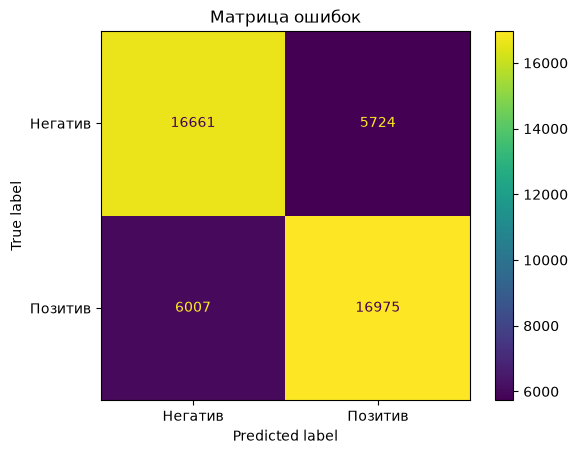

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Негатив", "Позитив"]
)

disp.plot()
plt.title("Матрица ошибок")
plt.show()
# по результату видим, что модель имеет примерно одинаковое число ложно положительных/отрицательных результатов


In [61]:
# Ручные тесты

# Тестовая выборка. Набор из фраз с явными и не явными эмоциональными окрасами.
test_phrases = [
    "Сегодня прекрасный день, я очень счастлив!",
    "Всё получилось отлично, я доволен результатом.",
    "Ужасный день, всё пошло наперекосяк.",
    "Я очень расстроен, ничего не получилось.",
    "Это просто великолепно, опять три часа ждать ответа.",
    "Я не доволен этой работой."
]

# Прогоним тестовую выборку по уже заготовленным функциям подготовки и векторизации
test_clean = [clean_text_for_ml(text) for text in test_phrases] # очистка
test_lemma = [lemmatize_text(text) for text in test_clean] # лмматизация
X_manual = vectorizer.transform(test_lemma) # векторизакция

In [ ]:
# Определить слабые места подхода
print(model.predict(X_manual)) # [1 1 0 0 1 1] результат показал, ошибки по варианту с сарказмом и частицей НЕ 
print(model.predict_proba(X_manual)) 
# по весам видно, что сарказм показал 73% уверенности, видимо модель высоко оценила слово "великолепно", но не смогла учесть контекст
# при этом последний варинат с НЕ был с ошибочным с 91% увереннстью, т.е. частица НЕ не была учтена
# подводя итог мы видим, что модель плохо справляется с контекстом, реагируя только на явно "весовые" слова
# подход TF-IDF + MLP не может показать значимых результатов т.к. в отличии от трансформеров не учитываются многие нюансы языка
# кроме подготовка текста включет очистку от знаков препинания и т.д. что размывает смысл фраз

[1 1 0 0 1 1]
[[2.22736474e-03 9.97772635e-01]
 [2.21006978e-04 9.99778993e-01]
 [9.89452150e-01 1.05478499e-02]
 [9.99991575e-01 8.42472349e-06]
 [2.70375896e-01 7.29624104e-01]
 [8.85644162e-02 9.11435584e-01]]
